<center>

# Analytical calculations for Incoherent test

#### Author: Daniel Lomholt Christensen

</center>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import mcstasscript as ms

#### Scattering from a thin incoherent sample

In [115]:
# First calculate the scattering from a thin sample
def n_measured_thin(flux, area, dist, rho, solid, cross, mu):
    return flux*area*rho*cross*dist*solid/4/np.pi*mu

In [119]:
# Calculated total scattered intensity, uncorrected for absorption
flux = 1e7 # incoming flux 25 mm from sample n/s/cm^2
area = 1 # square cm
dist = 1*1e-1 # Distance travelled by the neutron inside sample in cm
rho= 0.0719#1/13.827 # Unit cell density. AA^-3 (10^-24 cm)
cross=5.08 # Cross section in barns (10^-24 cm)
mu = 1 # Attenuation factor
solid = 4*np.pi# Solid angle in radians. A/r^2
n_tot = n_measured_thin(flux, area, dist, rho, solid, cross, mu)
solid = 0.001# Solid angle in radians. A/r^2
n_solid =n_measured_thin(flux, area, dist, rho, solid, cross, mu)
print(f"Total scattering= {n_tot:.4g}n/s\nScattering at detector={n_solid:.4g}n/s")

Total scattering= 3.653e+05n/s
Scattering at detector=29.07n/s


In [ ]:
# Calculated total scattered intensity, corrected for absorption
flux = 1e7 # incoming flux 25 mm from sample n/s/cm^2
area = 1 # square cm
dist = 1*1e-1 # Distance travelled by the neutron inside sample in cm
rho= 1/13.827 # Unit cell density. AA^-3 (10^-24 cm)
cross=5.08 # Cross section in barns (10^-24 cm)
mu = 0.928  # Attenuation factor
solid = 4*np.pi# Solid angle in radians. A/r^2
n_tot = n_measured_thin(flux, area, dist, rho, solid, cross, mu)
solid = 0.001# Solid angle in radians. A/r^2
n_solid =n_measured_thin(flux, area, dist, rho, solid, cross, mu)
print(f"Total scattering= {n_tot:.4g}n/s\nScattering at detector={n_solid:.4g}n/s")

Total scattering= 3.409e+05n/s
Scattering at detector=27.13n/s


#### Backscattering from a thick incoherent sample

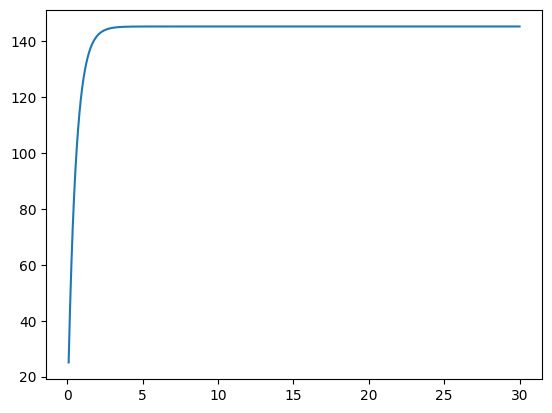

In [129]:
def n_measured_thick(flux, area, dist, rho, solid, cross, mu):
    return flux*area*rho*cross*solid/4/np.pi*mu* (1-np.exp(-2*mu*dist))/2/mu
# Calculated total scattered intensity, uncorrected for absorption
flux = 1e7 # incoming flux 25 mm from sample n/s/cm^2
area = 1 # square cm
dist = 1*1e-1 # Distance travelled by the neutron inside sample in cm
rho= 0.0719#1/13.827 # Unit cell density. AA^-3 (10^-24 cm)
cross=5.08 # Cross section in barns (10^-24 cm)
mu = 0.94622 # Attenuation factor in cm^-1
solid = 4*np.pi# Solid angle in radians. A/r^2
n_tot = n_measured_thick(flux, area, dist, rho, solid, cross, mu)
solid = 0.001# Solid angle in radians. A/r^2
n_solid =n_measured_thick(flux, area, dist, rho, solid, cross, mu)
# Now simulate for many thicknesses what their scattering is
dist = np.linspace(0.1,30,1000)
absolute_scattering = n_measured_thick(flux, area, dist, rho, solid, cross, mu)
fig, ax = plt.subplots()
ax.plot(dist, absolute_scattering)
#print(f"Total scattering= {n_tot:.4g}n/s\nScattering at detector={n_solid:.4g}n/s")